In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
import numpy as np
import pandas as pd

# Friedman (1991): 10 predictors, only the first 5 are relevant
rng = np.random.default_rng(42)
n_samples = 2000
noise_std = 1.0

# X_j ~ Uniform(0, 1), j = 1, ..., 10
X_np = rng.uniform(0.0, 1.0, size=(n_samples, 10))
X = pd.DataFrame(X_np, columns=[f"x{i}" for i in range(1, 11)])

# y = 10 sin(pi x1 x2) + 20 (x3 - 0.5)^2 + 10 x4 + 5 x5 + eps
eps = rng.normal(0.0, noise_std, size=n_samples)
y = (
    10.0 * np.sin(np.pi * X["x1"] * X["x2"])
    + 20.0 * (X["x3"] - 0.5) ** 2
    + 10.0 * X["x4"]
    + 5.0 * X["x5"]
    + eps
)

In [3]:
X = X.values.astype(float)
y = np.array(y).reshape(-1)

In [4]:
from experiment import run_parallel_experiments

temp_settings = [
    ("temp1", 1.0, 1.0),
    ("temp2", 2.0, 2.0),
    ("temp3", 3.0, 3.0),
    ("temp2-1", 2.0, 1.0),
    ("temp3-1", 3.0, 1.0),
]

all_results = {}

for temp_tag, start_temp, end_temp in temp_settings:
    notebook_name = f"syn1_Friedman_{temp_tag}"
    print(f"Running: {notebook_name} (start={start_temp}, end={end_temp})")

    results = run_parallel_experiments(
        X=X,
        y=y,
        ndpost=7000,
        nskip=3000,           # burn-in
        n_trees=100,
        notebook=notebook_name,
        tree_alpha=0.95,
        tree_beta=2.0,
        m_tries=10,
        n_runs=3, 
        n_chains=4,
        n_jobs=-2,
        base_split_seed=42,
        base_chain_seed=2026,
        store_preds=True,
        n_test_points=100,
        start_temp=start_temp,
        end_temp=end_temp,
        store_dir="store"
    )

    all_results[notebook_name] = results

print("All temperature settings finished.")

Running: syn1_Friedman_temp1 (start=1.0, end=1.0)


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 19.4min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 19.4min remaining: 19.4min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 19.5min finished
[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 21.8min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 21.8min remaining: 21.8min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 21.9min finished
[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 22.4min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 22.4min remaining: 22.4min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 22.5min finished


Running: syn1_Friedman_temp2 (start=2.0, end=2.0)


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 21.7min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 21.8min remaining: 21.8min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 21.9min finished
[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 21.7min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 21.8min remaining: 21.8min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 21.9min finished
[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 22.1min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 22.2min remaining: 22.2min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 22.3min finished


Running: syn1_Friedman_temp3 (start=3.0, end=3.0)


...

Running: syn1_Friedman_temp2-1 (start=2.0, end=1.0)


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 22.0min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 22.1min remaining: 22.1min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 22.2min finished
[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 22.1min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 22.1min remaining: 22.1min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 22.2min finished
[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 22.1min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 22.1min remaining: 22.1min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 22.3min finished


Running: syn1_Friedman_temp3-1 (start=3.0, end=1.0)


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 21.5min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 21.6min remaining: 21.6min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 21.6min finished
[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 21.3min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 21.4min remaining: 21.4min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 21.5min finished
[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed: 21.4min
[Parallel(n_jobs=-2)]: Done   2 out of   4 | elapsed: 21.5min remaining: 21.5min
[Parallel(n_jobs=-2)]: Done   4 out of   4 | elapsed: 21.8min finished


All temperature settings finished.


# Result

Detected temps: ['temp1', 'temp2', 'temp2-1', 'temp3', 'temp3-1']
Detected runs: [0, 1, 2]
Using chain index: 0

===== Run 000 (Chain 0) =====
RMSE comparison (rows=temp, cols=default/mtmh)


,default,mtmh
temp,,
temp1,1.156337,1.140877
temp2,1.155699,1.138400
temp2-1,1.171848,1.158767
temp3,1.163645,1.159133
temp3-1,1.170286,1.151666


CRPS comparison (rows=temp, cols=default/mtmh)


,default,mtmh
temp,,
temp1,0.655856,0.647791
temp2,0.658781,0.652748
temp2-1,0.661326,0.655723
temp3,0.675308,0.674126
temp3-1,0.664235,0.652089


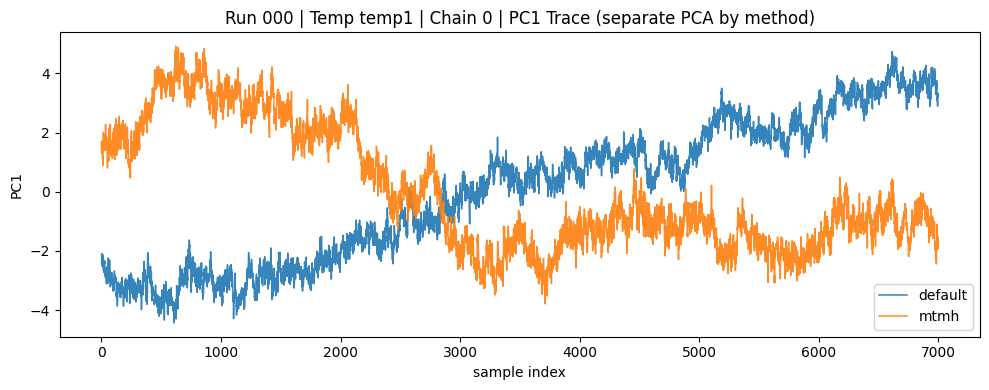

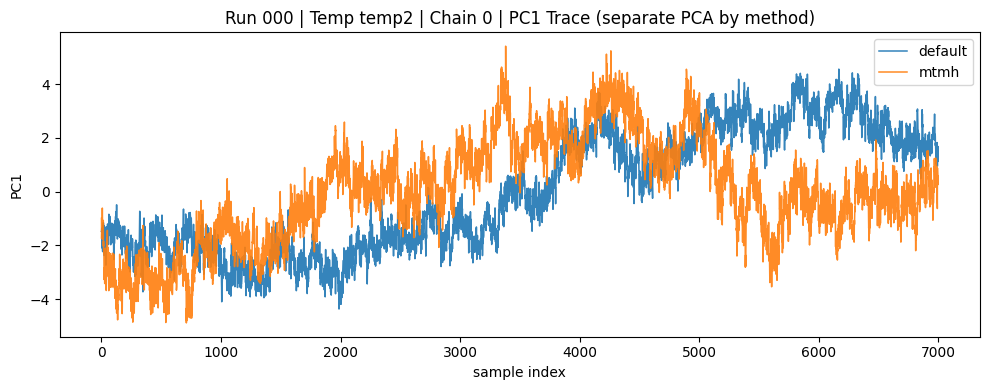

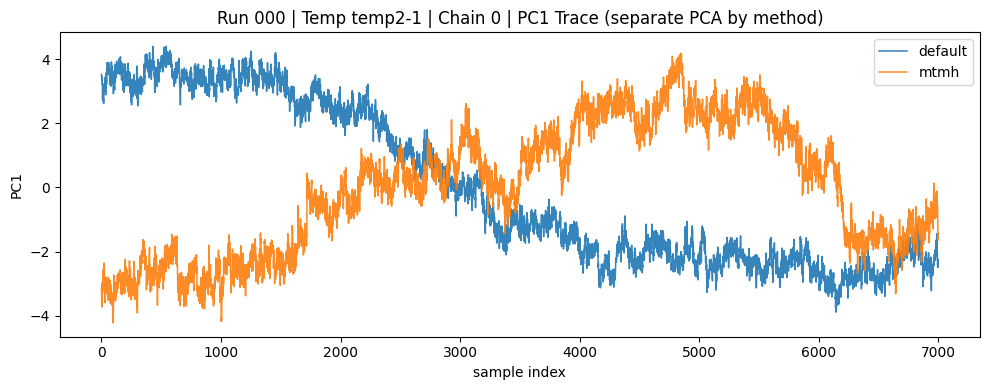

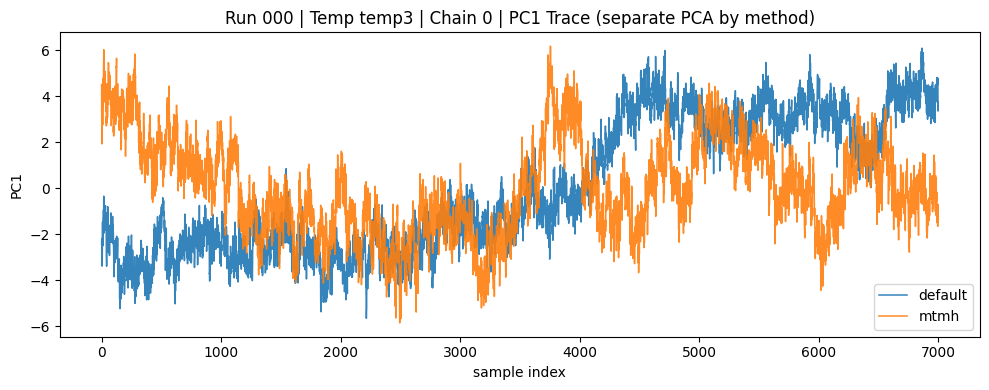

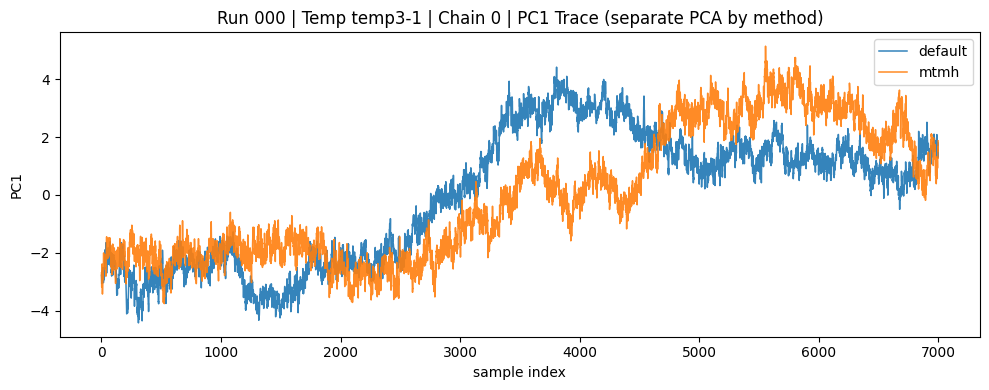

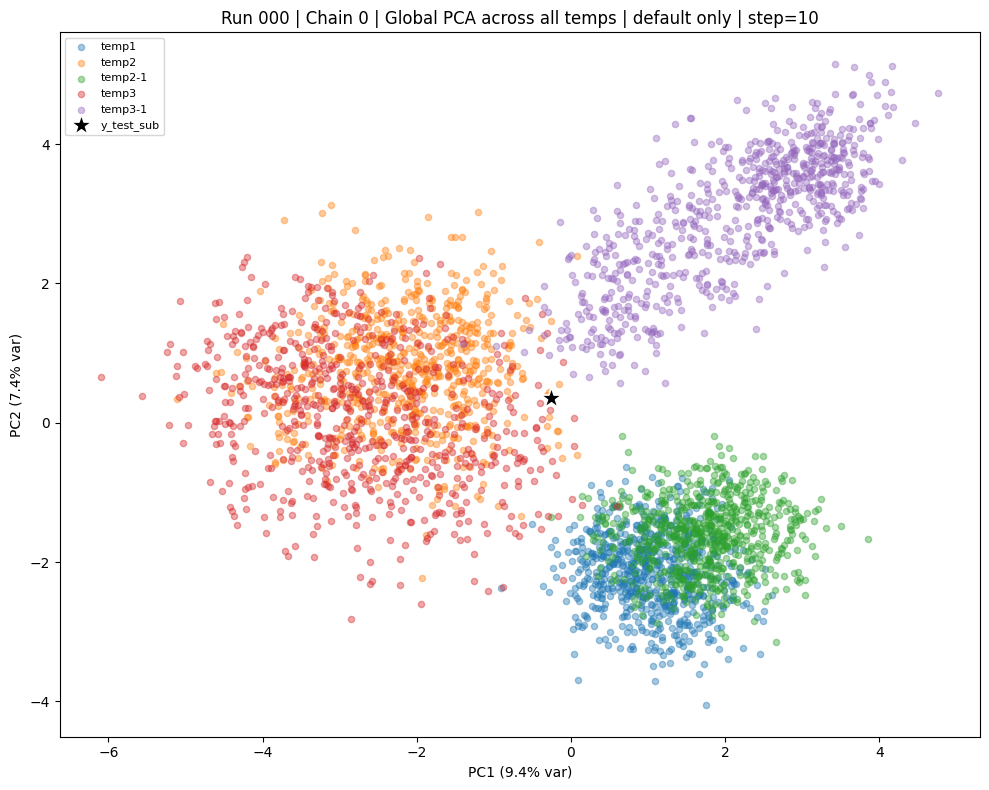

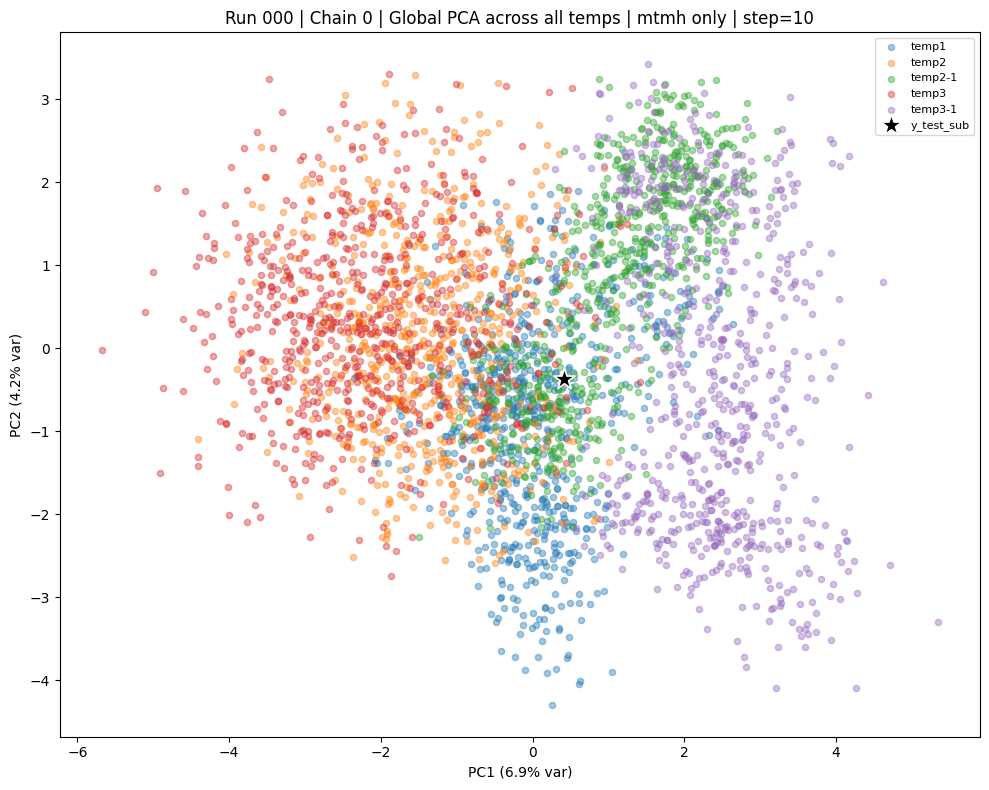


===== Run 001 (Chain 0) =====
RMSE comparison (rows=temp, cols=default/mtmh)


,default,mtmh
temp,,
temp1,1.170757,1.133265
temp2,1.139142,1.116723
temp2-1,1.184691,1.138315
temp3,1.132551,1.116577
temp3-1,1.194735,1.146739


CRPS comparison (rows=temp, cols=default/mtmh)


,default,mtmh
temp,,
temp1,0.670347,0.646517
temp2,0.653901,0.643622
temp2-1,0.678425,0.650948
temp3,0.657906,0.652430
temp3-1,0.682673,0.657904


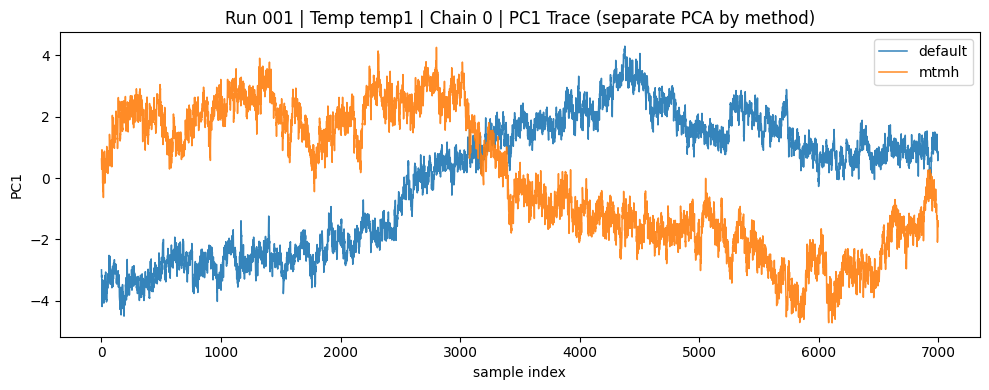

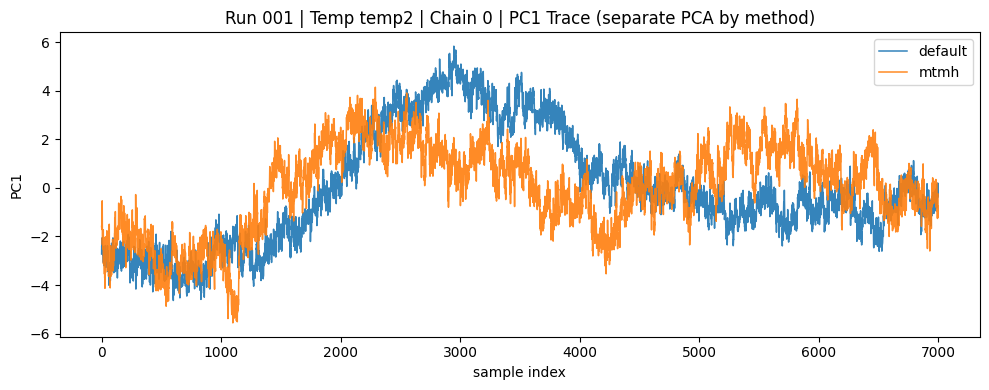

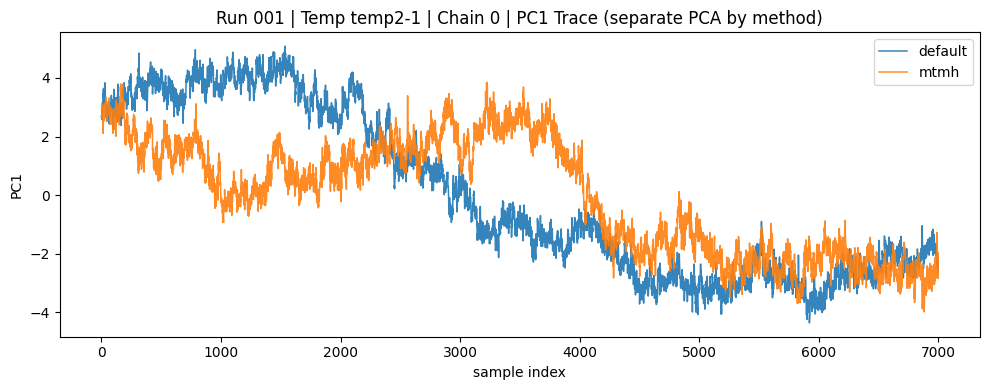

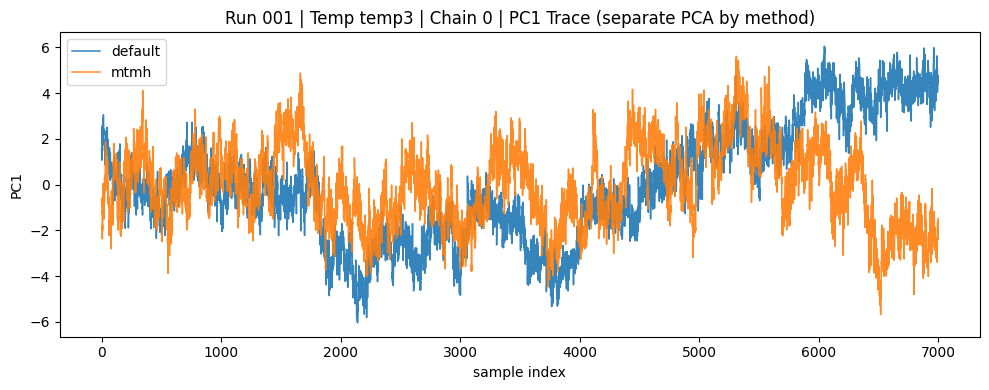

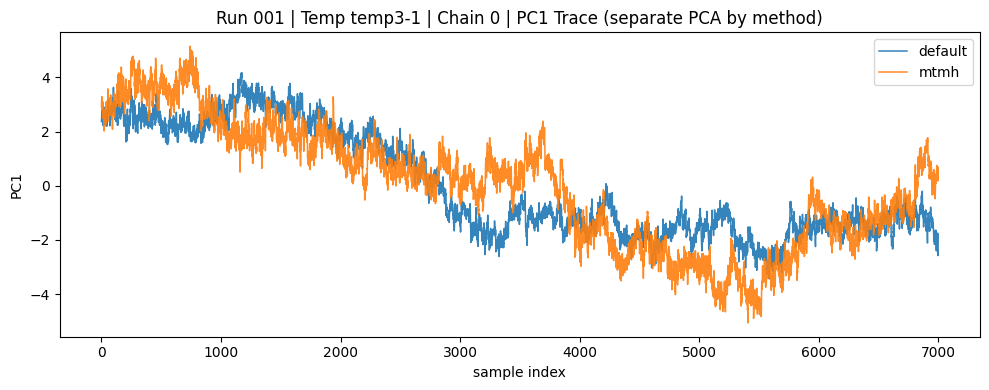

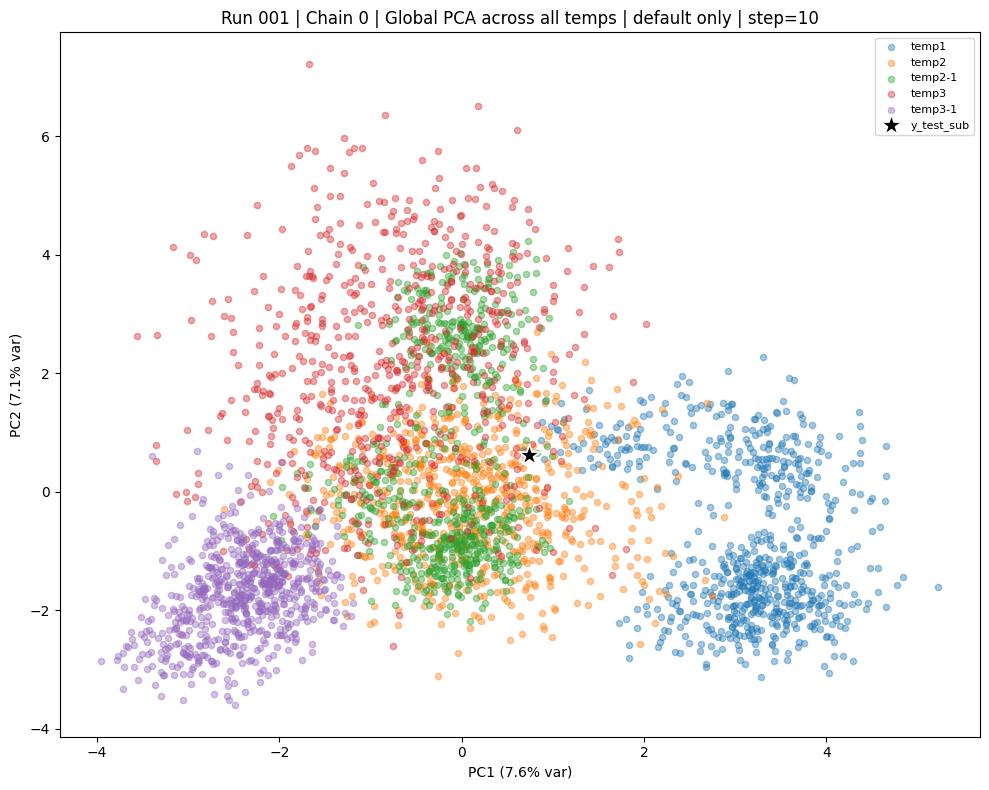

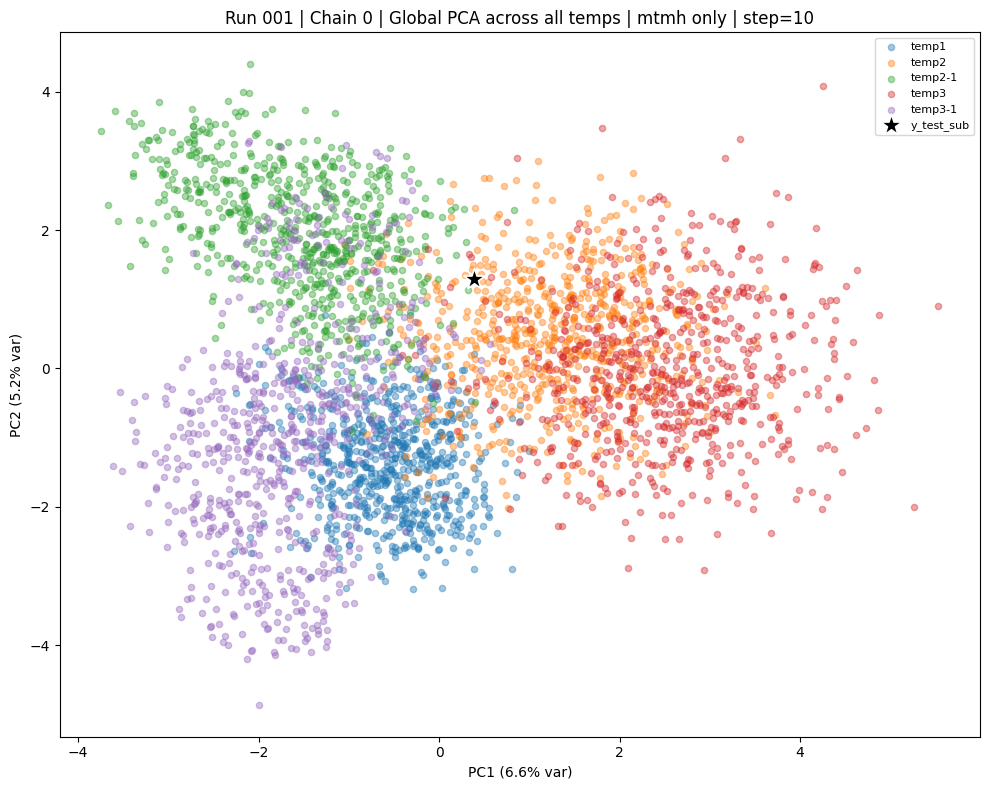


===== Run 002 (Chain 0) =====
RMSE comparison (rows=temp, cols=default/mtmh)


,default,mtmh
temp,,
temp1,1.320388,1.289273
temp2,1.236742,1.221316
temp2-1,1.297960,1.277834
temp3,1.246361,1.187850
temp3-1,1.298366,1.305207


CRPS comparison (rows=temp, cols=default/mtmh)


,default,mtmh
temp,,
temp1,0.763104,0.741931
temp2,0.706092,0.700014
temp2-1,0.745117,0.730801
temp3,0.716990,0.689971
temp3-1,0.749953,0.749780


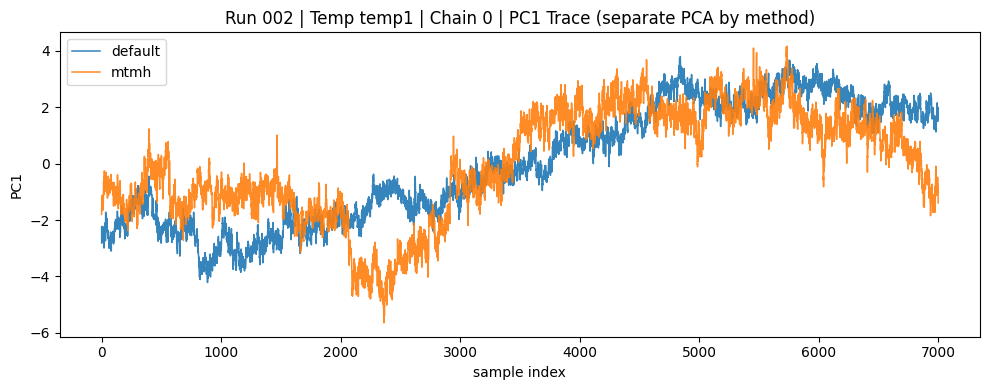

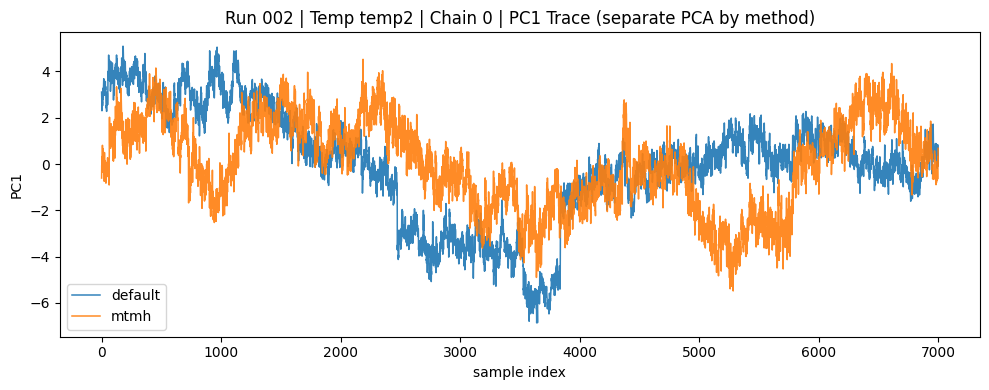

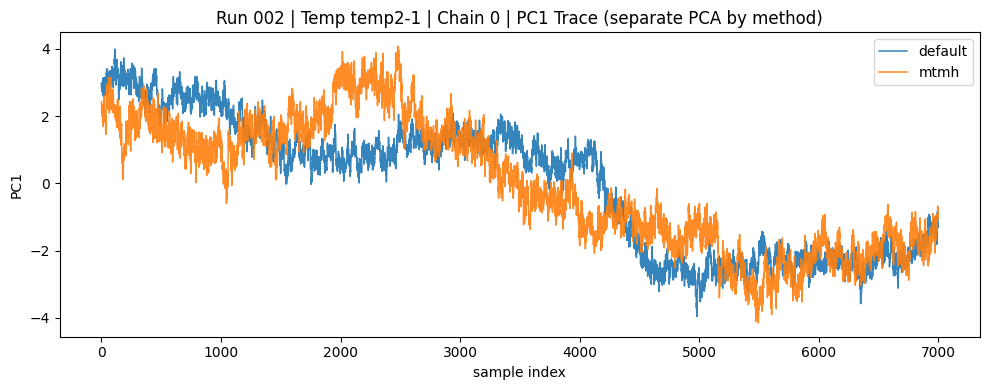

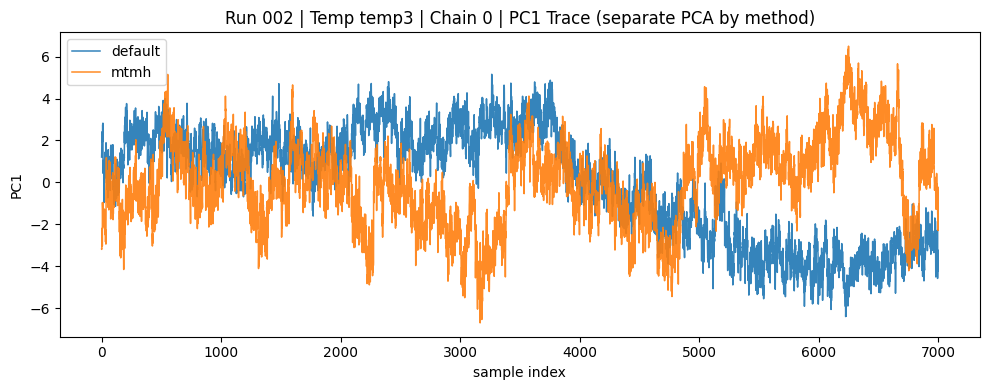

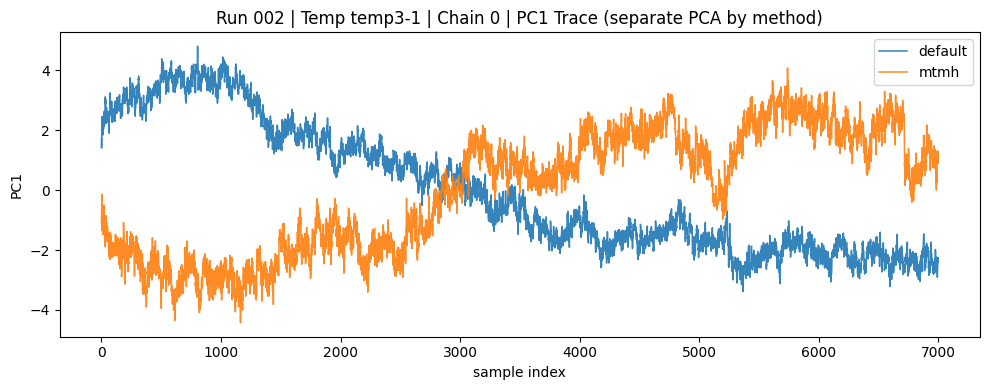

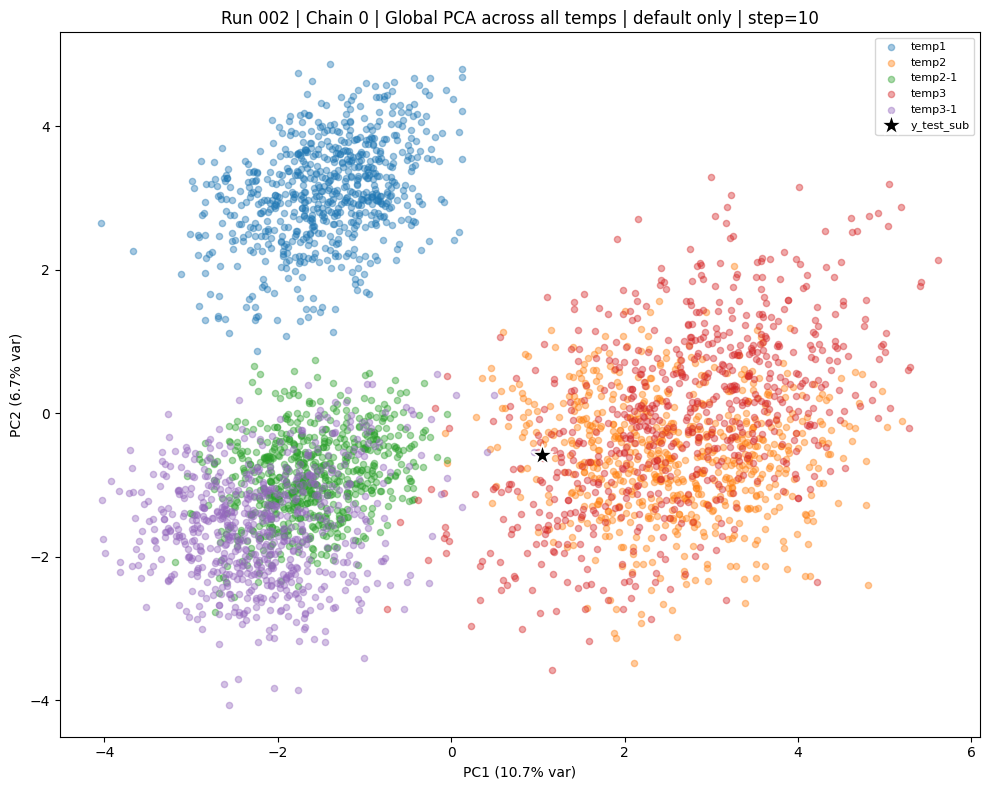

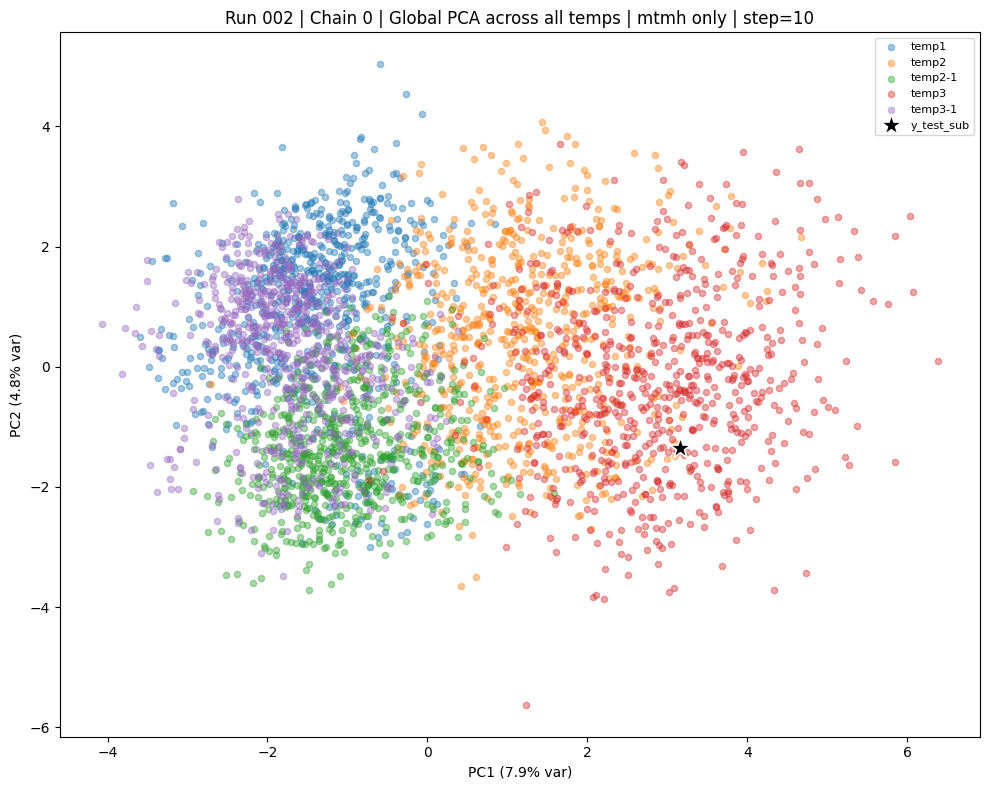

In [4]:
import re
import ast
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from IPython.display import display

STORE_DIR = Path("store")
NOTEBOOK_PREFIX = "syn1_Friedman"
CHAIN_INDEX = 0  # User-specified chain index (0-based)

def _parse_shape_from_header(csv_path):
    with open(csv_path, "r", encoding="utf-8") as f:
        first_line = f.readline().strip()
    # np.savetxt header is written as: '# original_shape=(...)'
    first_line = first_line.lstrip("#").strip()
    if not first_line.startswith("original_shape="):
        raise ValueError(f"Missing original_shape header in {csv_path}")
    return ast.literal_eval(first_line.split("=", 1)[1].strip())

def load_saved_numeric_csv(csv_path):
    shape = _parse_shape_from_header(csv_path)
    arr2d = np.loadtxt(csv_path, delimiter=",", comments="#")
    if arr2d.size == 0:
        return np.array([])
    if arr2d.ndim == 0:
        arr2d = arr2d.reshape(1, 1)
    elif arr2d.ndim == 1:
        arr2d = arr2d.reshape(1, -1)
    return arr2d.reshape(shape)

def discover_temps_and_runs(prefix=NOTEBOOK_PREFIX):
    rmse_dir = STORE_DIR / "subsample_rmse"
    pattern = re.compile(rf"^{re.escape(prefix)}_(?P<temp>[^_]+)__run(?P<run>\d{{3}})__default__subsample_rmse\.csv$")
    temp_to_runs = {}
    for p in rmse_dir.glob(f"{prefix}_*__default__subsample_rmse.csv"):
        m = pattern.match(p.name)
        if m is None:
            continue
        temp = m.group("temp")
        run = int(m.group("run"))
        temp_to_runs.setdefault(temp, set()).add(run)

    if not temp_to_runs:
        raise FileNotFoundError(
            f"No files found in {rmse_dir} for prefix '{prefix}'. "
            "Please run experiment first and check NOTEBOOK_PREFIX."
        )

    temps = sorted(temp_to_runs.keys())
    all_runs = sorted(set().union(*temp_to_runs.values()))
    return temps, all_runs

def build_metric_tables_for_run(run_id, temps, prefix=NOTEBOOK_PREFIX):
    rmse_rows = []
    crps_rows = []

    for temp in temps:
        base = f"{prefix}_{temp}__run{run_id:03d}"
        rmse_default_path = STORE_DIR / "subsample_rmse" / f"{base}__default__subsample_rmse.csv"
        rmse_mtmh_path = STORE_DIR / "subsample_rmse" / f"{base}__mtmh__subsample_rmse.csv"
        crps_default_path = STORE_DIR / "subsample_crps" / f"{base}__default__subsample_crps.csv"
        crps_mtmh_path = STORE_DIR / "subsample_crps" / f"{base}__mtmh__subsample_crps.csv"

        if not (rmse_default_path.exists() and rmse_mtmh_path.exists() and crps_default_path.exists() and crps_mtmh_path.exists()):
            continue

        rmse_default = load_saved_numeric_csv(rmse_default_path).reshape(-1)
        rmse_mtmh = load_saved_numeric_csv(rmse_mtmh_path).reshape(-1)
        crps_default = load_saved_numeric_csv(crps_default_path).reshape(-1)
        crps_mtmh = load_saved_numeric_csv(crps_mtmh_path).reshape(-1)

        # Chains are merged by averaging chain-level scalar metrics.
        rmse_rows.append({
            "temp": temp,
            "default": float(np.mean(rmse_default)),
            "mtmh": float(np.mean(rmse_mtmh)),
        })
        crps_rows.append({
            "temp": temp,
            "default": float(np.mean(crps_default)),
            "mtmh": float(np.mean(crps_mtmh)),
        })

    rmse_df = pd.DataFrame(rmse_rows).set_index("temp").sort_index()
    crps_df = pd.DataFrame(crps_rows).set_index("temp").sort_index()
    return rmse_df, crps_df

def load_preds_for_temp_run(temp, run_id, prefix=NOTEBOOK_PREFIX):
    base = f"{prefix}_{temp}__run{run_id:03d}"
    pred_default_path = STORE_DIR / "preds" / f"{base}__default__preds.csv"
    pred_mtmh_path = STORE_DIR / "preds" / f"{base}__mtmh__preds.csv"
    if not (pred_default_path.exists() and pred_mtmh_path.exists()):
        return None, None
    pred_default = load_saved_numeric_csv(pred_default_path)  # [n_chains, n_test, ndpost]
    pred_mtmh = load_saved_numeric_csv(pred_mtmh_path)
    return pred_default, pred_mtmh

def extract_chain_data(preds, chain_index=0):
    # [n_chains, n_test, ndpost] -> extract chain_index -> [ndpost, n_test]
    n_chains, n_test, ndpost = preds.shape
    if chain_index >= n_chains or chain_index < 0:
        raise ValueError(f"chain_index {chain_index} out of range [0, {n_chains-1}]")
    return preds[chain_index, :, :].T  # [ndpost, n_test]

def load_y_test_sub_for_run(run_id, temps, prefix=NOTEBOOK_PREFIX):
    for temp in temps:
        p = STORE_DIR / "subsample_y_test" / f"{prefix}_{temp}__run{run_id:03d}__subsample_y_test.csv"
        if p.exists():
            return load_saved_numeric_csv(p).reshape(-1)
    return None

def plot_pc1_trace_per_temp(run_id, temps, prefix=NOTEBOOK_PREFIX, chain_index=0):
    for temp in temps:
        pred_default, pred_mtmh = load_preds_for_temp_run(temp, run_id, prefix=prefix)
        if pred_default is None:
            continue

        mat_default = extract_chain_data(pred_default, chain_index)
        mat_mtmh = extract_chain_data(pred_mtmh, chain_index)

        pc1_default = PCA(n_components=1).fit_transform(mat_default)[:, 0]
        pc1_mtmh = PCA(n_components=1).fit_transform(mat_mtmh)[:, 0]

        plt.figure(figsize=(10, 4))
        plt.plot(pc1_default, label="default", color="#1f77b4", linewidth=1.1, alpha=0.9)
        plt.plot(pc1_mtmh, label="mtmh", color="#ff7f0e", linewidth=1.1, alpha=0.9)
        plt.title(f"Run {run_id:03d} | Temp {temp} | Chain {chain_index} | PC1 Trace (separate PCA by method)")
        plt.xlabel("sample index")
        plt.ylabel("PC1")
        plt.legend()
        plt.tight_layout()
        plt.show()

def plot_global_pca_per_run(run_id, temps, prefix=NOTEBOOK_PREFIX, chain_index=0, downsample_step=10):
    # IMPORTANT: PCA is fitted separately for default and mtmh.
    for method in ["default", "mtmh"]:
        mats = []
        temp_labels = []

        for temp in temps:
            pred_default, pred_mtmh = load_preds_for_temp_run(temp, run_id, prefix=prefix)
            if pred_default is None:
                continue

            pred = pred_default if method == "default" else pred_mtmh
            mat = extract_chain_data(pred, chain_index)
            mats.append(mat)
            temp_labels.extend([temp] * mat.shape[0])

        if not mats:
            print(f"Run {run_id:03d} | Chain {chain_index} | {method}: no prediction files found, skip global PCA.")
            continue

        X_method = np.vstack(mats)
        pca = PCA(n_components=2)
        pcs = pca.fit_transform(X_method)

        palette = plt.get_cmap("tab10")
        unique_temps = sorted(set(temp_labels))
        temp_color = {t: palette(i % 10) for i, t in enumerate(unique_temps)}

        y_test_sub = load_y_test_sub_for_run(run_id, temps, prefix=prefix)
        y_proj = None
        if y_test_sub is not None and y_test_sub.shape[0] == X_method.shape[1]:
            y_proj = pca.transform(y_test_sub.reshape(1, -1))[0]
        else:
            print(f"Run {run_id:03d} | Chain {chain_index} | {method}: y_test_sub missing or shape mismatch, skip y_test_sub projection.")

        plt.figure(figsize=(10, 8))
        cursor = 0
        for temp in temps:
            pred_default, pred_mtmh = load_preds_for_temp_run(temp, run_id, prefix=prefix)
            if pred_default is None:
                continue
            pred = pred_default if method == "default" else pred_mtmh
            mat = extract_chain_data(pred, chain_index)
            n = mat.shape[0]
            idx_full = np.arange(cursor, cursor + n)
            idx_ds = idx_full[::downsample_step]
            plt.scatter(
                pcs[idx_ds, 0],
                pcs[idx_ds, 1],
                s=20,
                alpha=0.4,
                color=temp_color[temp],
                marker="o",
                label=temp,
            )
            cursor += n

        if y_proj is not None:
            plt.scatter(
                y_proj[0],
                y_proj[1],
                s=260,
                c="black",
                marker="*",
                edgecolors="white",
                linewidths=1.2,
                label="y_test_sub",
                zorder=10,
            )

        evr = pca.explained_variance_ratio_
        plt.xlabel(f"PC1 ({evr[0] * 100:.1f}% var)")
        plt.ylabel(f"PC2 ({evr[1] * 100:.1f}% var)")
        plt.title(f"Run {run_id:03d} | Chain {chain_index} | Global PCA across all temps | {method} only | step={downsample_step}")

        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), fontsize=8, loc="best")
        plt.tight_layout()
        plt.show()

temps, runs = discover_temps_and_runs(prefix=NOTEBOOK_PREFIX)
print("Detected temps:", temps)
print("Detected runs:", runs)
print(f"Using chain index: {CHAIN_INDEX}")

for run_id in runs:
    print(f"\n===== Run {run_id:03d} (Chain {CHAIN_INDEX}) =====")
    rmse_df, crps_df = build_metric_tables_for_run(run_id, temps, prefix=NOTEBOOK_PREFIX)

    print("RMSE comparison (rows=temp, cols=default/mtmh)")
    display(rmse_df)

    print("CRPS comparison (rows=temp, cols=default/mtmh)")
    display(crps_df)

    # One figure per temp: default and mtmh PC1 trace in the same plot.
    plot_pc1_trace_per_temp(run_id, temps, prefix=NOTEBOOK_PREFIX, chain_index=CHAIN_INDEX)

    # Two global PCA figures per run (default and mtmh separately), downsampled by step=10.
    plot_global_pca_per_run(run_id, temps, prefix=NOTEBOOK_PREFIX, chain_index=CHAIN_INDEX, downsample_step=10)
